<center>
    <div style="font-family: 'Optima', sans-serif; color: #2C3E50; padding: 25px 35px; border: 2px solid #C0C0C0; border-radius: 12px; box-shadow: 0 10px 20px rgba(0, 0, 0, 0.15); background-color: #FBFBFB; max-width: 700px;">
        <font style="font-family: 'Optima', sans-serif; font-size: 64px; font-weight: bold; color: #2D6A4F;">Final Project</font>
        <br>
        <font style="font-family: 'Optima', sans-serif; font-size: 34px; color: #6A0572; font-weight: 600;">Ofek Zilber & Hadar Asraf</font>
        <br>
        <b style="font-family: 'Copperplate', serif; font-size: 26px; color: #34495E;">Introduction to Machine Learning –<br> Digital Sciences for High-Tech</b>
        <br>
        <i style="font-family: 'Optima', sans-serif; font-size: 22px; color: #95A5A6;">Spring 2024</i>
        <br>
    </div>
</center>

</center>

</center>

</center>

</center>

</center>

</center>

</center>

</center>

</center>
>


In [1]:
import warnings
import numpy as np
import pandas as pd
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, auc, confusion_matrix, ConfusionMatrixDisplay

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import chi2_contingency
import random

warnings.filterwarnings('ignore')

In [2]:
!pip install aif360[AdversarialDebiasing,Reductions,inFairness]
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.1 which is incompatible.


   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 3.1/350.9 MB 18.5 MB/s eta 0:00:19
    --------------------------------------- 5.0/350.9 MB 13.8 MB/s eta 0:00:26
   - -------------------------------------- 15.5/350.9 MB 30.4 MB/s eta 0:00:12
   - -------------------------------------- 15.5/350.9 MB 30.4 MB/s eta 0:00:12
   - -------------------------------------- 15.5/350.9 MB 30.4 MB/s eta 0:00:12
   - -------------------------------------- 16.8/350.9 MB 13.7 MB/s eta 0:00:25
   -- ------------------------------------- 18.6/350.9 MB 12.9 MB/s eta 0:00:26
   -- ------------------------------------- 24.1/350.9 MB 14.7 MB/s eta 0:00:23
   --- ------------------------------------ 26.7/350.9 MB 15.8 MB/s eta 0:00:21
   --- ------------------------------------ 26.7/350.9 MB 15.8 MB/s eta 0:00:21
   --- ------------------------------------ 27.5/350.9 MB 12.2 MB/s eta 0:00:27
   --- ------------------------------------ 28.8/35

<center><font size="6" color="#2D6A4F"><b>Part 1 - Exploration</b></font></center>


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;">
    💬 טעינת הנתונים
    </b>
    <br>
    <span style="font-size: 13px;">
        תחילה, טענו את קובץ ה-CSV באמצעות הפונקציה <code>read_csv</code> והמרנו אותו ל-DataFrame.<br>
        קראנו ל-DataFrame בשם <code>df</code> ויצרנו עותק שלו בשם <code>train</code>, עליו נבצע את השינויים הראשונים. הקובץ המקורי נשמר בשם <code>df</code> לצורך גיבוי במידת הצורך.
    </span>
</div>

</div>


In [3]:
df = pd.read_csv("train.csv")
train = df

<div style="text-align: right; direction: rtl">
    <b>💬 על מנת להתחיל בחקירת הדאטה, תחילה היה עלינו להתאים את הנתונים בצורה שמתאימה לניתוח. לשם כך, ביצענו מספר שלבים:</b>
<ul>
    <li>המרה של כל הערכים בפיצ'רים הבינאריים לערכים מספריים, כך שנוכל לעבוד איתם בצורה נוחה יותר.</li>
    <li>לאחר מכן, החלטנו להמיר את ערכי הפיצ'ר "Education" לערכים מספריים, על ידי דירוג רמת ההשכלה באופן הבא:
        <ol style="direction: rtl; text-align: right;">
            <li>תיכון נחשב כרמה הנמוכה ביותר.</li>
            <li>"אחר" – הנחנו כי מדובר בהכשרות מקצועיות או בלמידה עצמית.</li>
            <li>תואר ראשון.</li>
            <li>תואר שני.</li>
            <li>דוקטורט.</li>
        </ol>
    </li>
    <li>לבסוף, הוספנו את העמודה <code>len_of_stack</code>, המתארת את כמות ה-<code>stack_experience</code> שיש לכל מועמד, ובכך נתנו מידע נוסף שיכול לסייע בניתוח הנתונים.</li>
</ul>
    הפעולות הללו נועדו להכין את הדאטה בצורה מיטבית לקראת המשך תהליך החקירה והניתוח.
</div>


In [4]:
def preprocess_data(df):
    df['worked_in_the_past'].replace({'T':1, 'F':0}, inplace=True)
    df['age_group'].replace({'old':1, 'young':0}, inplace=True)
    df['disability'].replace({'Yes':1, 'No':0}, inplace=True)
    df['is_dev'].replace({'developer':1, 'non-developer':0}, inplace=True)
    df['mental_issues'].replace({'Yes':1, 'No':0}, inplace=True)

    df['education'].replace({'High school':1, 'other':2, 'BA/BSc':3, 'MA/MSc':4, 'Phd':5}, inplace=True)

    len_of_stack = df['stack_experience'].apply(lambda x: len(x.split(';')) if pd.notnull(x) else None) 
    df.insert(df.columns.get_loc('stack_experience')+1, 'len_of_stack', len_of_stack)

    return df

train = preprocess_data(train)

<div style="text-align: right; direction: rtl;">
    <b>💬 נתונים סטטיסטיים על סט הנתונים.</b>
    <br>
    <span style="font-size: 13px;">
בדקנו כמה רשומות קיימות בסט הנתונים, וכמה ערכים ריקים יש לכל פיצ'ר.
    </span>
</div>

In [5]:
print(f'The number of records in the dataset is: {train.shape[0]}')
missing_values_per_column = train.isnull().sum()
missing_values_per_column

The number of records in the dataset is: 55462


ID                         0
worked_in_the_past      1765
age_group               2540
disability              3681
is_dev                  2090
education               3016
sex                     3228
mental_issues           2415
years_of_experience     2564
A                       2135
B                       3535
C                       3002
D                       2619
country                 2019
prev_salary             2664
stack_experience       14042
len_of_stack           14042
label                      0
dtype: int64

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות בנושא מילוי ערכים ריקים:</b>
        <ol>
            <li>מכיוון שחסרים ערכים רבים, נימנע מלמחוק רשומות עם ערכים חסרים בשלב זה.</li>
            <li>נבדוק את כמות הערכים החסרים המצטברים בכל רשומה.</li>
            <li>נבחן כל פיצ'ר בנפרד ונקבע את הדרך המתאימה ביותר למילוי הערכים החסרים בו.</li>
            <li>בנוגע לפיצ'ר <code>stack_experience</code>, שנמצא חסר ב-25.32% מהרשומות, נדרש להתייחס אליו באופן שונה משאר הפיצ'רים.
                בנוסף, נבדוק את כמות סוגי הערכים הקיימים בו.</li>
        </ol>
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>💬 בשלב זה, אנחנו מעוניינים לחקור את התפלגות הפיצ'רים הקטגוריאליים בסט הנתונים.</b>
        <br><br>
        לצורך כך, יצרנו שתי פונקציות עזר. 
        הראשונה היא <code>categorical_distribution</code>, אשר מאפשרת לנו להציג את התפלגות הערכים של כל פיצ'ר קטגוריאלי בצורה ברורה וויזואלית.
        <br>
        הפונקציה מבצעת את הפעולות הבאות:
        <ul>
            <li>סופרת ומציגה את כמות הערכים השונים בכל פיצ'ר.</li>
            <li>מדפיסה את מספר ההופעות והאחוז היחסי של כל ערך.</li>
            <li>במידה והפיצ'ר מכיל יותר מ-10 ערכים ייחודיים, הפונקציה תציג את חמשת הערכים הכי נפוצים ואת חמשת הערכים הכי פחות נפוצים.</li>
        </ul>
        <br>
         הפונקציה השנייה בשם <code>categorical_distribution_with_label</code> אשר מטרתה היא לראות באופן ויזואלי את ההבדל בין ההתפלגות הכללית לבין התפלגות הערכים שקיבלו לייבל 1 לכל פיצ'ר קטגוריאלי.
        <br>
בחרנו להשתמש במבחן חי-בריבוע (Chi-Square Test) כדי לבדוק אם יש קשר מובהק בין הפיצ'ר לבין הלייבל. המבחן משווה בין ההתפלגות הכללית של הערכים להתפלגות הערכים שלהם יש לייבל 1, וכך קובע אם יש קשר משמעותי בין המשתנים.
        <br>
        הפונקציה פועלת באופן הבא:
        <ul>
            <li>בודקת את מספר הערכים הייחודיים בעמודת הפיצ'ר הנבחר.</li>
            <li>מדפיסה את ההתפלגות הכללית של הערכים ואת ההתפלגות עבור לייבל 1 בלבד.</li>
            <li>מייצרת שני גרפי עמודות: האחד מציג את ההתפלגות הכללית והשני מציג את ההתפלגות עבור לייבל 1.</li>
            <li>מבצעת את מבחן חי-בריבוע כדי לבדוק האם יש קשר מובהק בין העמודה לבין הלייבל על ידי השוואה בין ההתפלגות הכללית של הערכים לבין ההתפלגות של הערכים שקיבלו לייבל 1.</li>
            <li>מציגה את תוצאות המבחן, כולל ערך ה-p והמסקנה האם יש קשר מובהק או לא.</li>
        </ul>
    </span>
</div>

In [6]:
#To check how many types of values ​​are in each feature:

def categorical_distribution(df, column):
    # Calculate and print value statistics
    unique_value_count = df[column].nunique()
    value_counts = df[column].value_counts()
    value_percentages = df[column].value_counts(normalize=True) * 100
    
    print('-' * 50)
    print(f"There are {unique_value_count} different types of values in column '{column}':\n")
    print(f"Value counts for column '{column}':")
    
    def print_value_counts(values, percentages):
        for value, count, percentage in zip(values.index, values.values, percentages.values):
            print(f"{value}: {count} ({percentage:.2f}%)")

    # Print up to 10 unique values, if more print top 5 and bottom 5.
    if unique_value_count <= 10:
        print_value_counts(value_counts, value_percentages)
    else:
        print("Top 5 values:")
        print_value_counts(value_counts.head(5), value_percentages.head(5))
        print("...")
        print("Bottom 5 values:")
        print_value_counts(value_counts.tail(5), value_percentages.tail(5))
    print('-' * 50)


In [7]:
def plot_distribution_by_label(df, column, top_n=30, alpha=0.05):

    label_column = df.columns[-1]
    column_all = df[column].value_counts()
    df_label_1 = df[df[label_column] == 1]
    column_label_1 = df_label_1[column].value_counts()

    # Chi-Square test
    observed = pd.concat([column_all, column_label_1], axis=1, keys=['All', 'Label 1']).fillna(0)
    chi2_stat, p_value, dof, expected = chi2_contingency(observed)
    print(f"\nChi2 Statistic: {chi2_stat:.4f}, P-Value: {p_value:.4f}")
    
    # Conclusion from Chi-Square test
    if p_value < alpha:
        print(f"Conclusion: There is significant evidence that '{column}' affects the likelihood of receiving label 1.\n")
    else:
        print(f"Conclusion: There is no significant evidence that '{column}' affects the likelihood of receiving label 1.\n")
    
    # Distribution for top 30 categories
    column_all_top = column_all.head(top_n)
    column_label_1_top = column_label_1.head(top_n)

    # Plots
    plt.figure(figsize=(14, 6))
    
    # Distribution plot for the general population
    plt.subplot(1, 2, 1)
    sns.barplot(x=column_all_top.index, y=column_all_top.values, palette='viridis', edgecolor='black')
    plt.title(f'Categories for General Population')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    
    # Distribution plot for label 1
    plt.subplot(1, 2, 2)
    sns.barplot(x=column_label_1_top.index, y=column_label_1_top.values, color=sns.color_palette('viridis')[4], edgecolor='black')
    plt.title(f'Categories for Label 1')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()


<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>💬 נבדוק את הנתונים על הפיצ'ר <code>'sex'</code>:</b>
    </span>
</div>

--------------------------------------------------
There are 3 different types of values in column 'sex':

Value counts for column 'sex':
Male: 48777 (93.38%)
Female: 2490 (4.77%)
Other: 967 (1.85%)
--------------------------------------------------

Chi2 Statistic: 25.6756, P-Value: 0.0000
Conclusion: There is significant evidence that 'sex' affects the likelihood of receiving label 1.



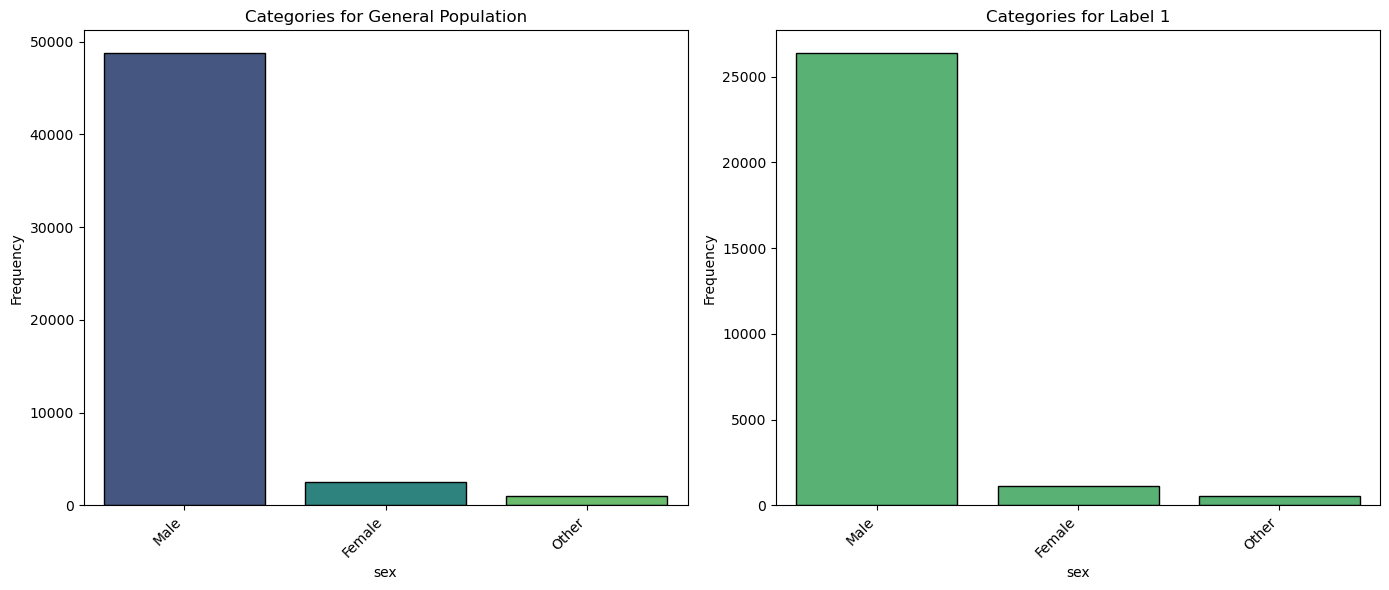

In [8]:
categorical_distribution(train, 'sex')
plot_distribution_by_label(train, 'sex')

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות בנושא הפיצ'ר <code>sex</code>:</b>
        <ul>
            <li>נראה שאין ערכים חריגים בעמודת <code>sex</code>, שכן ישנם רק 3 סוגים: Male, Female ו-Other.</li>
            <li>קיימת הטיה מגדרית משמעותית, כאשר 93.38% מהנתונים שייכים לקטגוריה "Male". זה עלול להשפיע על תוצאות המודלים אם לא נטפל בהטיה זו כראוי.</li>
            <li>מבחן חי-בריבוע מצביע על כך שיש קשר מובהק בין הערכים בעמודת <code>sex</code> לבין הסיכוי לקבל לייבל 1, עם ערך p של 0.0000.</li>
            <li>מכיוון שהקטגוריות בעמודת <code>sex</code> כתובות במילים ולא במספרים, וכן מכיוון שישנן 3 קטגוריות ולא שתיים, נשתמש בטכניקת <code>One-Hot Encoding</code> כדי להמיר את הנתונים ולהתאים אותם למודלים.</li>
        </ul>
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>💬 נבדוק את הנתונים על הפיצ'ר <code>'C'</code>:</b>
    </span>
</div>

--------------------------------------------------
There are 7 different types of values in column 'C':

Value counts for column 'C':
aa: 21082 (40.19%)
ww: 10215 (19.47%)
hr: 7850 (14.96%)
rhz: 5223 (9.96%)
br: 4882 (9.31%)
mn: 2632 (5.02%)
ca: 576 (1.10%)
--------------------------------------------------

Chi2 Statistic: 2.8411, P-Value: 0.8285
Conclusion: There is no significant evidence that 'C' affects the likelihood of receiving label 1.



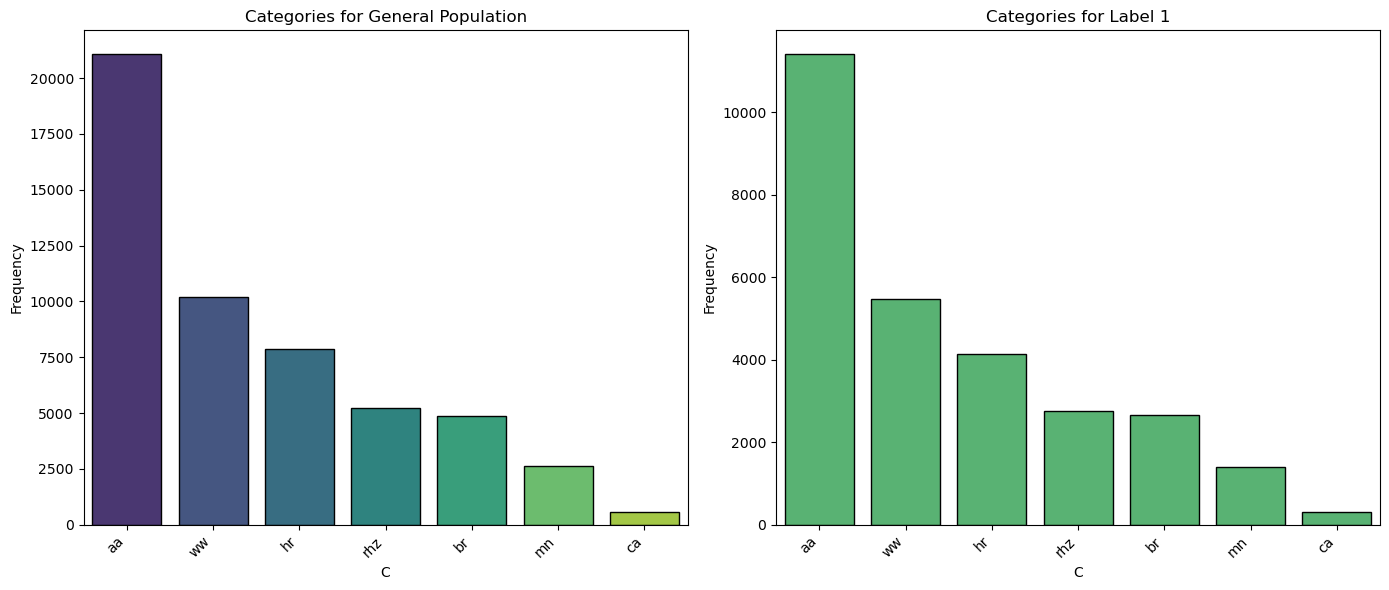

In [9]:
categorical_distribution(train, 'C')
plot_distribution_by_label(train, 'C')

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות בנושא הפיצ'ר <code>C</code>:</b>
        <ul>
            <li>נראה שאין ערכים חריגים בעמודת <code>C</code>, כגון טעויות כתיב או ערכים בלתי תקינים.</li>
            <li>מכיוון שהערכים בעמודת <code>C</code> כתובים במילים ולא במספרים, נשתמש בטכניקת <code>One-Hot Encoding</code> כדי להמיר את הנתונים ולהתאים אותם למודלים.</li>
            <li>מבחן חי-בריבוע מצביע על כך שאין קשר מובהק בין הערכים בעמודת <code>C</code> לבין הסיכוי לקבל לייבל 1, עם ערך p של 0.8285.</li>
            <li>בשל העובדה שזהו פיצ'ר אנונימי, קשה להסיק מסקנות נוספות בשלב זה.</li>
        </ul>
    </span>
</div>

</div>


<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>💬 נבדוק את הנתונים על הפיצ'ר <code>'country'</code>:</b>
    </span>
</div>

--------------------------------------------------
There are 170 different types of values in column 'country':

Value counts for column 'country':
Top 5 values:
United States of America: 10690 (20.00%)
Germany: 3967 (7.42%)
India: 3891 (7.28%)
United Kingdom of Great Britain and Northern Ireland: 3462 (6.48%)
Canada: 1988 (3.72%)
...
Bottom 5 values:
Burkina Faso: 1 (0.00%)
Gambia: 1 (0.00%)
Mauritania: 1 (0.00%)
Saint Kitts and Nevis: 1 (0.00%)
Mali: 1 (0.00%)
--------------------------------------------------

Chi2 Statistic: 156.8845, P-Value: 0.7386
Conclusion: There is no significant evidence that 'country' affects the likelihood of receiving label 1.



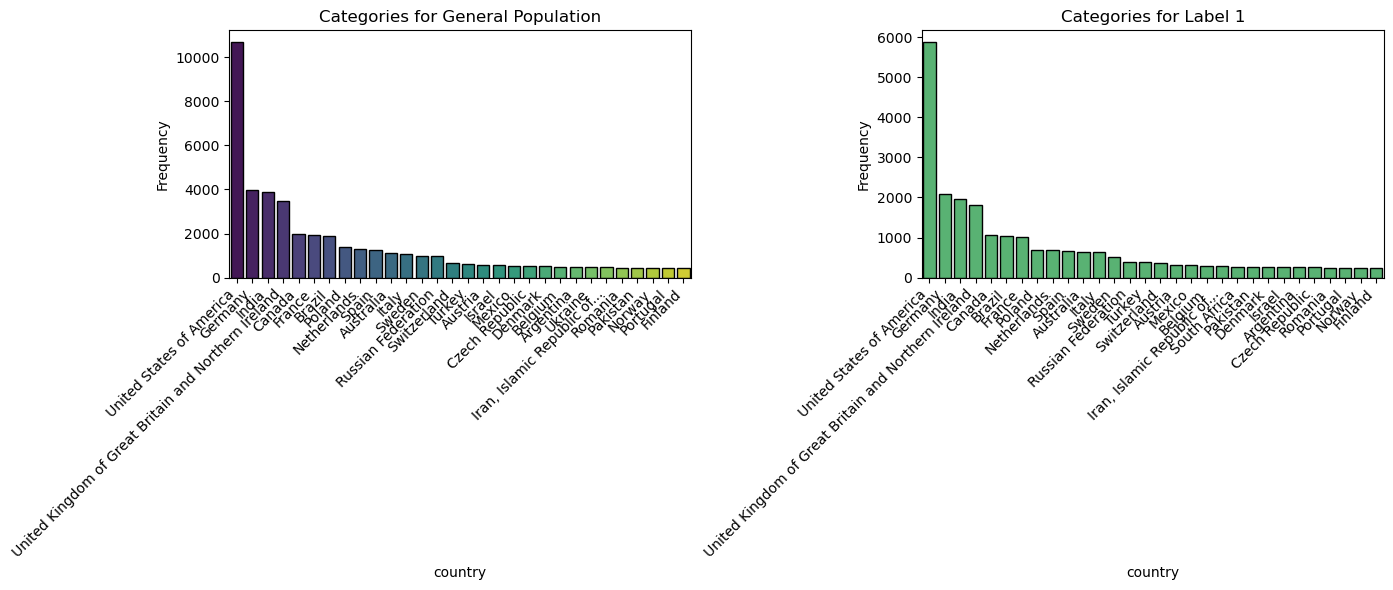

In [10]:
categorical_distribution(train, 'country')
plot_distribution_by_label(train, 'country')

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות בנושא הפיצ'ר <code>country</code>:</b>
        <ul>
            <li>ההתפלגות של הפיצ'ר <code>country</code> אינה נורמלית, כאשר יש ריכוז גבוה של מועמדים מארה"ב.</li>
            <li>מכיוון שכחמישית מהמועמדים מגיעים מארה"ב, יש לוודא שהמודל לא ייטה לטובת מועמדים ממדינה זו.</li>
            <li>נצטרך לבדוק שכל 170 המדינות בעמודה הן מדינות אמיתיות ולוודא שאין אנומליות כגון שגיאות כתיב או ערכים בלתי תקינים.</li>
            <li>מבחן חי-בריבוע מצביע על כך שאין קשר מובהק בין הערכים בעמודת <code>country</code> לבין הסיכוי לקבל לייבל 1, עם ערך p של 0.7386. כלומר, הפיצ'ר הזה אינו משפיע על קבלת הלייבל ויכול לגרום לאפליה על בסיס מוצא, ולכן הוחלט לא להשתמש בו במודל.</li>
        </ul>
    </span>
</div>


** תזכורת להתייחס מתישהו: **
למרות שהורדנו את הנתון הזה עם הצדקה,
הוא עדין היה לנו שימושי להסביר את המשכורות הנמוכות במדינות.
את הפערים בין המשכורות הגבוהות לנמוכות.

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>💬 נבדוק את הנתונים על הפיצ'ר <code>'age_group'</code>:</b>
        <br>
        על אף שהפיצ'ר כבר בינארי ולא קטגוריאלי, רצינו לבדוק האם קיימת הטיה בקבוצות הגיל, במטרה למנוע גילנות במודל. 
        בפיצ'ר זה, הערך 0 מייצג את קבוצת הצעירים והערך 1 מייצג את קבוצת המבוגרים.
    </span>
</div>

--------------------------------------------------
There are 2 different types of values in column 'age_group':

Value counts for column 'age_group':
0.0: 34545 (65.28%)
1.0: 18377 (34.72%)
--------------------------------------------------

Chi2 Statistic: 13.4879, P-Value: 0.0002
Conclusion: There is significant evidence that 'age_group' affects the likelihood of receiving label 1.



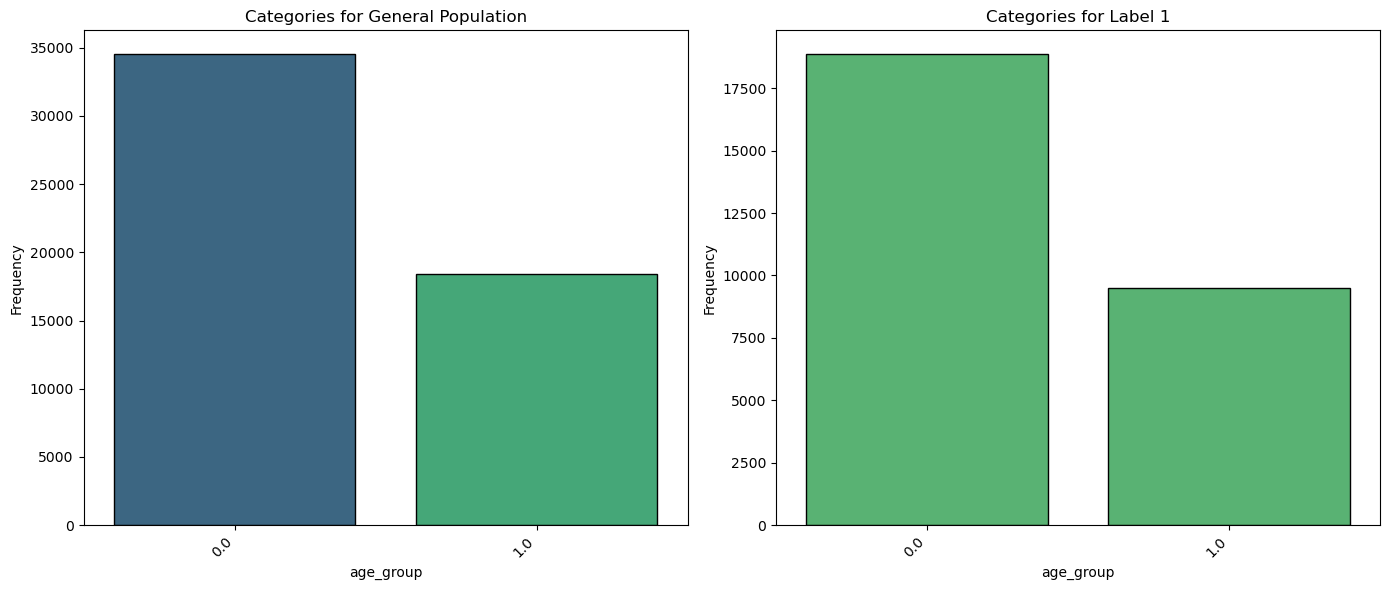

In [11]:
categorical_distribution(train, 'age_group')
plot_distribution_by_label(train, 'age_group')

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות בנושא הפיצ'ר <code>age_group</code>:</b>
        <ul>
            <li>נראה שאין ערכים חריגים בעמודת <code>age_group</code>, שכן ישנם רק 2 סוגים: 0 ו-1, המייצגים את קבוצת הצעירים וקבוצת המבוגרים, בהתאמה.</li>
            <li>המודל עלול לגרום להטיה של גילנות מכיוון שיש ייצוג גבוה יותר לצעירים (65.28%) בנתונים הכלליים.</li>
            <li>מבחן חי-בריבוע מצביע על כך שיש קשר מובהק בין הערכים בעמודת <code>age_group</code> לבין הסיכוי לקבל לייבל 1, עם ערך p של 0.0002.</li>
            <li>היות ויש הטיה מובהקת במודל הקשורה לגיל, יש לשקול צעדים כדי למנוע הטיית גילנות, כגון איזון הנתונים או שימוש בטכניקות אחרות לשיפור המודל.</li>
        </ul>
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>💬 נבדוק את הנתונים על הפיצ'רים <code>'disability'</code> ו-<code>'mental_issues'</code>:</b>
        <br>
        למרות שהפיצ'רים הללו הם בינאריים ולא קטגוריאליים, רצינו לבדוק האם קיימות הטיות שעלולות ליצור העדפה לא הוגנת ולהוביל לאפליה כלפי אנשים עם נכויות פיזיות או נפשיות.
        <br>
        בפיצ'רים אלו, הערך 0 מייצג אנשים שאינם מוגבלים פיזית ואינם סובלים ממחלה נפשית, בעוד שהערך 1 מייצג את אלו שכן.
    </span>
</div>


--------------------------------------------------
There are 2 different types of values in column 'disability':

Value counts for column 'disability':
0.0: 50281 (97.10%)
1.0: 1500 (2.90%)
--------------------------------------------------

Chi2 Statistic: 2.3988, P-Value: 0.1214
Conclusion: There is no significant evidence that 'disability' affects the likelihood of receiving label 1.



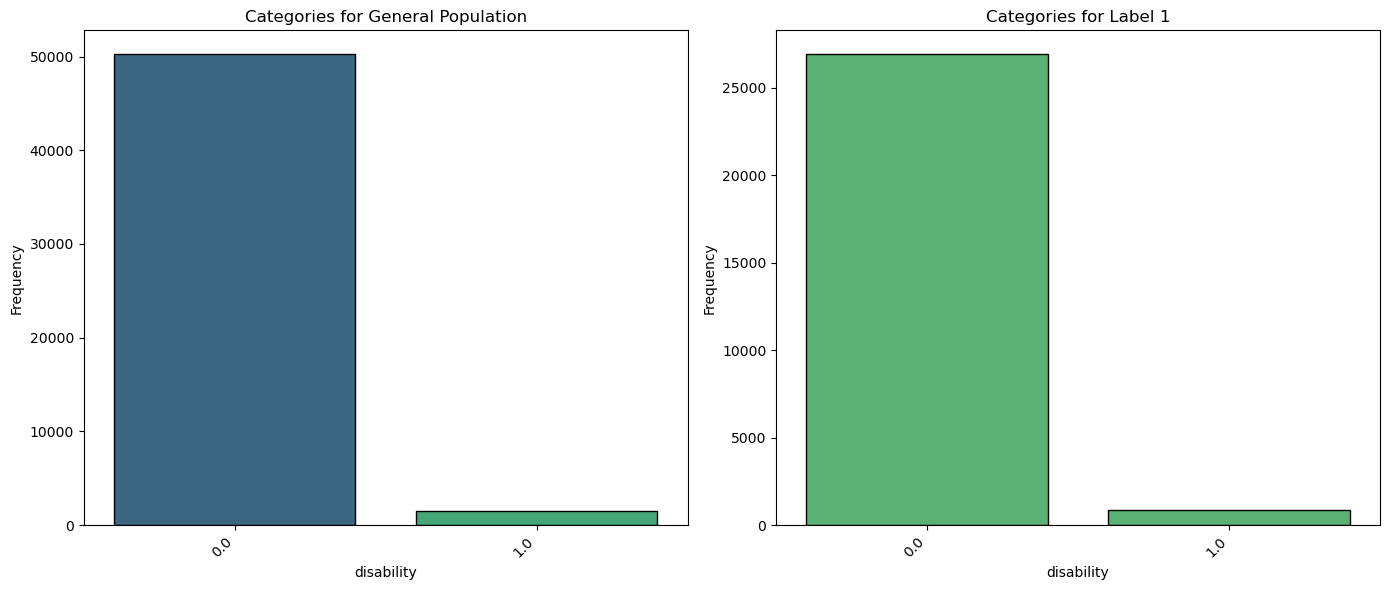

--------------------------------------------------
There are 2 different types of values in column 'mental_issues':

Value counts for column 'mental_issues':
0.0: 41107 (77.49%)
1.0: 11940 (22.51%)
--------------------------------------------------

Chi2 Statistic: 9.9651, P-Value: 0.0016
Conclusion: There is significant evidence that 'mental_issues' affects the likelihood of receiving label 1.



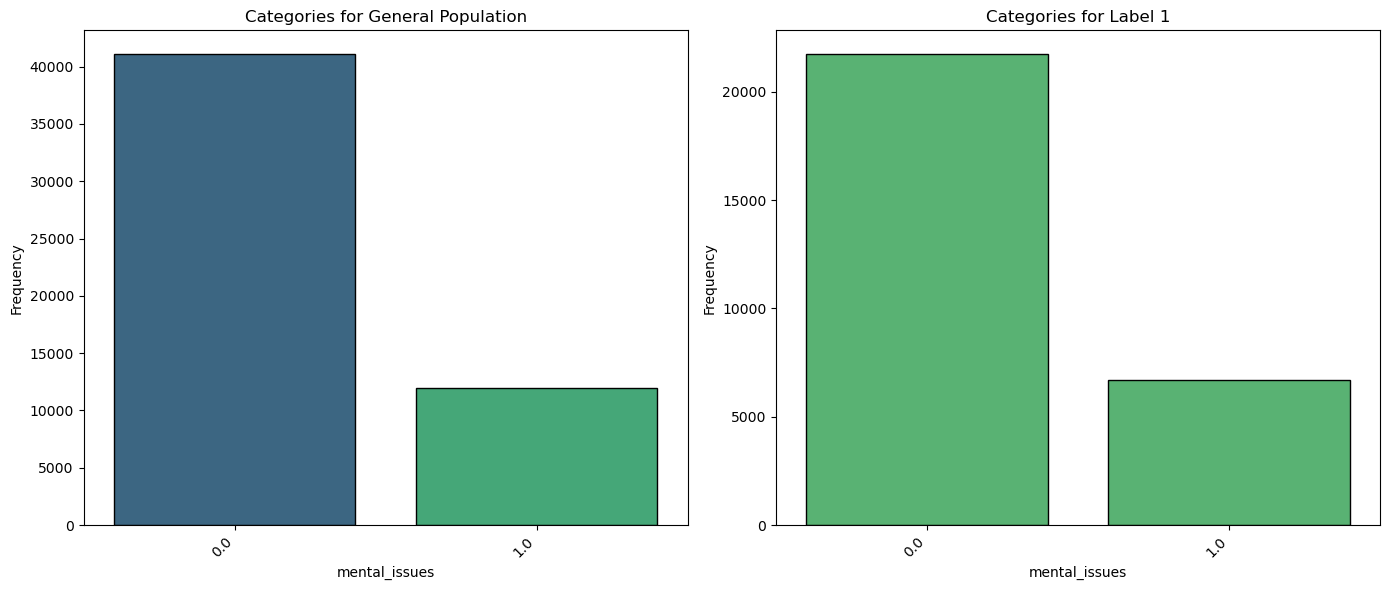

In [12]:
categorical_distribution(train, 'disability')
plot_distribution_by_label(train, 'disability')
categorical_distribution(train, 'mental_issues')
plot_distribution_by_label(train, 'mental_issues')

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות בנושא הפיצ'רים <code>disability</code> ו-<code>mental_issues</code>:</b>
        <ul>
            <li>נראה שאין ערכים חריגים בעמודות <code>disability</code> ו-<code>mental_issues</code>, שכן ישנם רק 2 סוגים: 0 ו-1, המייצגים את האנשים שאינם מוגבלים פיזית או נפשית, ואת אלו שכן, בהתאמה.</li>
            <li>עבור הפיצ'ר <code>disability</code>, מבחן חי-בריבוע מצביע על כך שאין עדות מובהקת לכך שהערכים בעמודה זו משפיעים על הסיכוי לקבל לייבל 1, עם ערך p של 0.1214. עם זאת, מכיוון שיש כמות גדולה מאוד של אנשים שאינם מוגבלים פיזית לעומת אלו שכן, יש להיזהר מהטיה אפשרית שעלולה לגרום לאי העדפה לא הוגנת כלפי אנשים עם נכויות.</li>
            <li>עבור הפיצ'ר <code>mental_issues</code>, מבחן חי-בריבוע מצביע על כך שיש קשר מובהק בין הערכים בעמודה זו לבין הסיכוי לקבל לייבל 1, עם ערך p של 0.0016. חשוב לבחון לעומק את המשמעות של קשר זה כדי לוודא שהמודל אינו מטה את התוצאות על בסיס מצבים נפשיים.</li>
        </ul>
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ❓ התמודדות עם משתנים קטגוריאליים
        <br>
    </b>
    <span style="font-size: 12px;">
        נסכם את ההחלטות שלנו בנוגע לפיצ'רים קטגוריאליים:
        <br>
        • עבור הפיצ'רים הבינאריים <code>worked_in_the_past</code>, <code>age_group</code>, <code>handicap</code>, <code>is_dev</code>, <code>mental_issues</code>, המרנו את הערכים השמיים לערכים מספריים על מנת להקל על עיבוד המידע ולשפר את ביצועי המודל.
        <br>
        • הפיצ'ר <code>country</code> הוסר מהנתונים, שכן נמצא כי למרות הקורלציה הגבוהה בין מדינה לקבלה לעבודה, אין התאם ישיר למידע המועיל למודל.
        <br>
        • הפיצ'ר <code>stack_experience</code> הוסר בהתחלה, אך לאחר מכן הוחזר לשימוש לאחר שנמצא שהוא תורם באופן משמעותי לביצועי המודל.
        <br>
        • הפיצ'רים <code>C</code> ו-<code>SEX</code> הוסבו לדמויים (dummy variables) על מנת לייעל את השימוש בהם במודל.
        <br>
        • הפיצ'ר <code>education</code> הוסב למשתנה אורדינלי כדי לשקף את הסדר ההיררכי של רמות החינוך בצורה טובה יותר.
        <br>
        • השינויים הללו מבוצעים על מנת לשפר את איכות הנתונים ולייעל את עיבוד המידע. אנו מניחים שפעולות אלו יובילו לביצועים טובים יותר של המודל וישפרו את היכולת לחזות תוצאות בצורה מדויקת יותר.
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <b>💬 כעת נחקור את המשתנים הנומריים.</b>
    <br>
    <span style="font-size: 13px;">
        <ul>
            <li>החלטנו שבשלב זה לא רלוונטי לבדוק האם הפיצ'רים מתפלגים נורמלית, מכיוון שלא נשתמש ב-PCA לבחירת פיצ'רים, ולא נבדוק את הנתונים באמצעות בוקס פלוט.</li>
            <li>בשלב זה נבדוק רק את הקורלציה בין המשתנים הנומריים.</li>
        </ul>
    </span>
</div>
</div>


--------------------------------------------------
Top 5 Strongest Correlations:

B and years_of_experience: 0.90 (90.09% correlation)
B and age_group: 0.69 (68.86% correlation)
age_group and years_of_experience: 0.68 (67.65% correlation)
label and len_of_stack: 0.58 (58.20% correlation)
D and label: 0.41 (40.64% correlation)
--------------------------------------------------
Correlation Matrix for Numeric Features: 



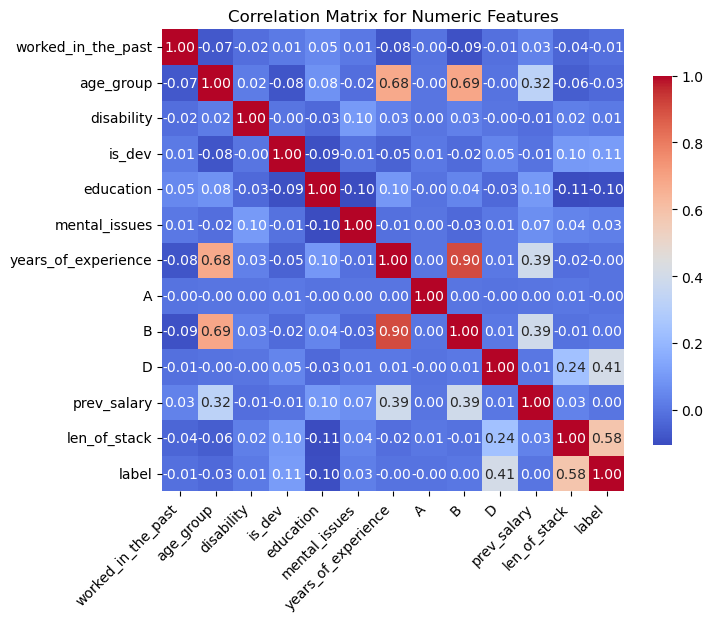

In [13]:
def plot_numeric_correlation_matrix(df, n=5):

    numeric_df = df.select_dtypes(include=[int, float])
    correlation_matrix = numeric_df.iloc[:, 1:].corr()

    correlation_pairs = (
        correlation_matrix.where(
            ~correlation_matrix.apply(lambda x: x.index >= x.name)).stack().reset_index())
    
    correlation_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    top_n_correlations = correlation_pairs.iloc[correlation_pairs['Correlation'].abs().argsort()[-n:][::-1]]

    print('-' * 50)
    print(f"Top {n} Strongest Correlations:\n")
    for _, row in top_n_correlations.iterrows():
        print(f"{row['Feature1']} and {row['Feature2']}: {row['Correlation']:.2f} ({abs(row['Correlation'])*100:.2f}% correlation)")
    print('-' * 50)

    print("Correlation Matrix for Numeric Features: \n")
    plt.figure(figsize=(7.5, 6))  # גודל פלט ביניים
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
    plt.title("Correlation Matrix for Numeric Features")
    plt.xticks(rotation=45, ha='right')  # סיבוב שמות הפיצ'רים באלכסון על ציר ה-X
    plt.yticks(rotation=0)  # שמות הפיצ'רים על ציר ה-Y נשארים ישרים
    plt.show()


plot_numeric_correlation_matrix(train)

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 13px;">
        <b>✏️ מסקנות:</b>
        <ul>
            <li>בתחילה כללנו גם את <code>ID</code> בבדיקות הקורלציות, אך לאחר שזיהינו זאת במטריצה, הסרנו אותו מהניתוח.</li>
            <li>הקורלציה הגבוהה בין <code>B</code> ל-<code>years_of_experience</code> (90%) מעידה על כך שניתן אולי להשלים נתונים חסרים באחד הפיצ'רים באמצעות השני. בנוסף, יש לשקול לוותר על אחד מהם בשל הקורלציה החזקה ביניהם.</li>
            <li>הקורלציה הגבוהה בין <code>B</code> ל-<code>age_group</code> (69%) והקורלציה בין <code>age_group</code> ל-<code>years_of_experience</code> (68%) מצביעות על קשר הדוק בין גיל, ניסיון מקצועי וקטגוריית <code>B</code>. זה עשוי לרמז על כך שגיל וניסיון מקצועי משפיעים באופן משמעותי על קטגוריית <code>B</code>.</li>
            <li>הקורלציה החזקה בין <code>B</code> ל-<code>years_of_experience</code> אינה מפתיעה, מאחר ולשתיהן יש קורלציה דומה עם <code>prev_salary</code>. זה מצביע על כך שניסיון מקצועי וקטגוריית <code>B</code> משחקים תפקיד משמעותי בקביעת השכר הקודם.</li>
            <li>הקורלציה בין <code>label</code> ל-<code>len_of_stack</code> (58%) והקורלציה בין <code>D</code> ל-<code>label</code> (41%) מצביעות על קשר בינוני. מצאנו שככל שלמתמודד יש יותר כלים, כלומר ככל שהאורך גדול יותר - הוא נוטה פחות להתקבל.</li>
            <li>רוב הקורלציות בין יתר הפיצ'רים הן נמוכות, מה שמצביע על כך שאין קשר חזק ביניהן. מסקנה זו מחזקת את ההחלטה להתמקד בחמשת הקורלציות החזקות ביותר בשלב זה.</li>
        </ul>
    </span>
</div>


<center><font size="6" color="#2D6A4F"><b>Part 2 - Preprocessing</b></font></center>

<div style="text-align: right; direction: rtl;">
    <b>💬 השלב הראשון בעיבוד המקדים הוא להפוך משתנים קטגוריאליים לנומריים באמצעות ONE HOT ENCODER.</b>
    <br>
    <span style="font-size: 13px;">
        <ul>
            <li>בנינו פונקציה שיוצרת עמודות של דאמיס (Dummy Variables) עבור המשתנים הקטגוריאליים ומכניסה אותן לאחר הפיצ'ר המקורי.</li>
            <li>הפעלנו את הפונקציה על הפיצ'רים <code>C</code> ו-<code>SEX</code>.</li>
        </ul>
    </span>
</div>


In [14]:
#Creates dummy variables for a categorical column and inserts the new columns after the original one.
def insert_dummies(df, column):
    column_dummies = pd.get_dummies(df[column], prefix=column)
    col_index = df.columns.get_loc(column)
    for i, col in enumerate(column_dummies.columns):
        df.insert(col_index + 1 + i, col, column_dummies[col].astype(int))

#dummy variables for a "C"
insert_dummies(train, 'C')

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 12px;">
        <b>💬 החלטנו למלא את הערכים החסרים בפיצ'ר <code>sex</code> לפי ההתפלגות הקיימת של הערכים המלאים.</b>
        <br>
        זאת מתוך מטרה לשמור על ההתפלגות הכללית ולמנוע הטיות פוטנציאליות. לשם כך, לפני ביצוע תהליך ה-One Hot Encoding (יצירת דאמיס) על הפיצ'ר,<br>
        השתמשנו בפונקציה שכתבנו <code>fill_na_with_probabilities</code>, אשר ממלאת את הערכים החסרים בהתבסס על ההתפלגות של הנתונים הקיימים.
        <br>
        לאחר מכן, ביצענו את תהליך ה-One Hot Encoding למגדר.
    </span>
</div>


In [15]:
#A function that fills Null values ​​according to the distribution of rest of the values
def fill_na_with_probabilities(df, column):
    counts = df[column].value_counts(normalize=True)
    values = counts.index
    probabilities = counts.values
    missing_values = df[column].isnull().sum()
    mask = df[column].isna()
    df.loc[mask, column] = np.random.choice(values, size=missing_values, p=probabilities)
    return df[column]


train['sex'] = fill_na_with_probabilities(train, 'sex')
insert_dummies(train, 'sex')

# Checking that the process was successful
missing_values_per_column2 = train.isnull().sum()
missing_values_per_column2

ID                         0
worked_in_the_past      1765
age_group               2540
disability              3681
is_dev                  2090
education               3016
sex                        0
sex_Female                 0
sex_Male                   0
sex_Other                  0
mental_issues           2415
years_of_experience     2564
A                       2135
B                       3535
C                       3002
C_aa                       0
C_br                       0
C_ca                       0
C_hr                       0
C_mn                       0
C_rhz                      0
C_ww                       0
D                       2619
country                 2019
prev_salary             2664
stack_experience       14042
len_of_stack           14042
label                      0
dtype: int64

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 12px;">
        <b>💬 טיפול בערכים ריקים לפי שורות.</b>
        <br>כעת אנו מעוניינים לבדוק כמה רשומות מכילות יותר מדי ערכים חסרים, ובמקרים אלו לשקול להסירן.<br>
        רשומות שחסרים להן יותר מדי נתונים עלולות להיות לא שימושיות לאימון המודל, ולכן העדיפות היא להסיר אותן כדי לשפר את דיוק התחזיות.<br>
        כתבנו פונקציה שמוציאה גרף המציג את התפלגות הרשומות לפי כמות הערכים הריקים בכל רשומה.
    </span>
</div>


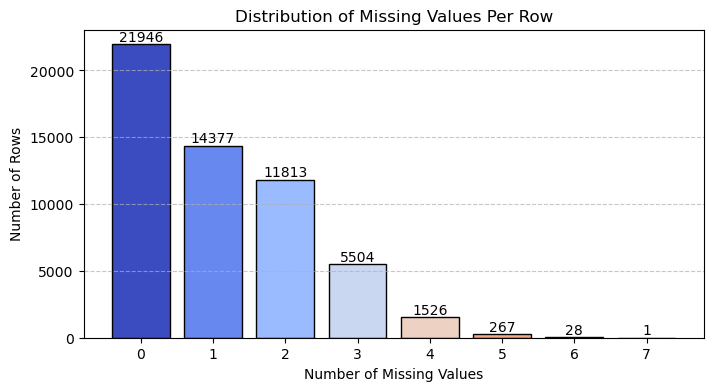

In [16]:
def plot_missing_values_distribution(df):
    missing_values_count = df.isnull().sum(axis=1)
    missing_values_distribution = missing_values_count.value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    bars = plt.bar(missing_values_distribution.index, missing_values_distribution.values, color=cmap(np.linspace(0, 1, len(missing_values_distribution))), edgecolor='black')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

    plt.title('Distribution of Missing Values Per Row')
    plt.xlabel('Number of Missing Values')
    plt.ylabel('Number of Rows')
    plt.xticks(missing_values_distribution.index)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


plot_missing_values_distribution(train)

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 12px;">
        <b>✏️ מסקנות לגבי מחיקת רשומות:</b>
        <br>
        כתבנו פונקציה שמוחקת כל רשומה שבה חסרים 5 פיצ'רים ומעלה, מכיוון שאי אפשר ללמוד הרבה מרשומות שחסרים בהן כשליש מהנתונים (5 ומעלה פיצ'רים מתוך 17).<br>
        ישנן רק 296 רשומות כאלה, מספר זניח ביחס לסט נתונים בגודל של כ-55,000 רשומות. <br>
        את הדאטה עם מספר השורות החדש נשמור במשתנה חדש שייקרא <code>train2</code> וזה הדאטה שנמשיך לעבוד איתו מעכשיו,
        וזאת על מנת שנוכל לחזור אחורה במידה ונרצה להשתמש בסט לפני שנמחקו ממנו נתונים.
    </span>
</div>

In [17]:
def drop_rows_with_X_missing_values(df, X):
    missing_count_per_row = df.isnull().sum(axis=1)
    df_filtered = df[missing_count_per_row < X]
    
    return df_filtered
    
train2 = drop_rows_with_X_missing_values(train, 5)

missing_values_per_column = train2.isnull().sum()
missing_values_per_column

ID                         0
worked_in_the_past      1711
age_group               2466
disability              3593
is_dev                  2039
education               2942
sex                        0
sex_Female                 0
sex_Male                   0
sex_Other                  0
mental_issues           2358
years_of_experience     2494
A                       2076
B                       3424
C                       2920
C_aa                       0
C_br                       0
C_ca                       0
C_hr                       0
C_mn                       0
C_rhz                      0
C_ww                       0
D                       2537
country                 1950
prev_salary             2601
stack_experience       13754
len_of_stack           13754
label                      0
dtype: int64

<div style="text-align: right; direction: rtl;">
    <span style="font-size: 12px;">
        <b>💬 כעת נרצה לטפל בנתונים החריגים</b>
        <br>
        החלטנו למלא את הדאטה באמצעות KNN על מנת לקבל תוצאות מיטביות במילוי נתונים חסרים.<br>
        עם זאת, לפני שנבצע את המילוי באמצעות KNN, נרצה לטפל בנתונים החריגים כדי להבטיח שהשיטה תעבוד בצורה האפקטיבית ביותר.
    </span>
</div>

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 12px;"><br>
       ❓האם קיימים נתונים חריגים (outliers) בדאטה?
        <br>
    </b>
    <span style="font-size: 12px;">
        <ul>
            <li>ישנם מועמדים עם שנות ניסיון בעבודה (יש ערך בעמודת <code>years_of_experience</code>), אך בעמודת <code>worked_in_the_past</code> מצוין 0 (לא עבד בעבר).</li>
            <li>ישנם מועמדים שמצוין כי "עבדו בעבר" (1), אך הערך בעמודת <code>years_of_experience</code> שווה לאפס.</li>
            <li>שמנו לב שיש ערכים ריקים בעמודת <code>worked_in_the_past</code>, גם עבור מועמדים שיש להם ערך בעמודת <code>years_of_experience</code>.</li>
            <li>ישנם מועמדים מתחת לגיל 35 (מסווגים כצעירים), אך עם 17 או יותר שנות ניסיון, מה שמצביע על סיווג לא נכון בעמודת <code>age_group</code>, תחת ההנחה שיצאנו ממנה שגיל תחילת העבודה הוא 18, כך שמדובר במועמדים בני 35 ומעלה.</li>
            <li>בנוסף, שמנו לב שיש ערכים ריקים בעמודת <code>age_group</code> עבור מועמדים שיש להם ערך בעמודת <code>years_of_experience</code>.</li>
            <li>לא זיהינו נתונים חריגים במשכורות הגבוהות, מאחר והיו הרבה משכורות זהות ברמות השכר הגבוהות ביותר, אך כן זיהינו חריגות בנתונים על שכר נמוך בפיצ'ר <code>prev_salary</code>, עם שכר המופיע במספרים נמוכים מאוד.</li>
        </ul>
    </span>
</div>


In [18]:
# Displaying the 10 highest salaries
highest_salaries = df['prev_salary'].nlargest(10)
print("Top 10 highest salaries:")
print(highest_salaries)

# Displaying the 10 lowest salaries
lowest_salaries = df['prev_salary'].nsmallest(10)
print("\nTop 10 lowest salaries:")
print(lowest_salaries)

# Counting the number of values below 1000 in 'prev_salary' column
print("\nNumber of records with 'prev_salary' below 1000:")
print(train2[train2['prev_salary'] < 1000].shape[0])


Top 10 highest salaries:
5265     224000.0
14248    223115.0
27232    223000.0
32156    223000.0
34587    223000.0
50083    223000.0
34762    222864.0
49512    222540.0
8211     222476.0
25558    222000.0
Name: prev_salary, dtype: float64

Top 10 lowest salaries:
8472     1.0
30491    1.0
33358    1.0
47746    1.0
22366    2.0
40872    2.0
10977    3.0
23418    3.0
49696    3.0
19070    4.0
Name: prev_salary, dtype: float64

Number of records with 'prev_salary' below 1000:
346


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 12px;"><br>
        ✏️מסקנות ופעולות על נתונים חריגים:
        <br>
    </b>
    <span style="font-size: 12px;">
        <ul>
            <li>נשנה את הערך בעמודת <code>worked_in_the_past</code> מ-0 ל-1 עבור מועמדים שיש להם ערך בעמודת <code>years_of_experience</code>, תוך הדגשה שהשינוי נעשה רק עבור מועמדים עם אפס שנות ניסיון ולא למי שיש ערך חסר (NaN).</li>
            <li>עבור מועמדים עם ערך ריק בעמודת <code>worked_in_the_past</code>, נמלא את הערך ב-1 אם יש להם שנות ניסיון, וב-0 אם יש להם אפס שנות ניסיון. כך נמלא חלק מהערכים הריקים.</li>
            <li>נעדכן את הסיווג בעמודת <code>age_group</code> ממועמדים שסווגו כצעירים (0) למבוגרים (1) אם יש להם 17 או יותר שנות ניסיון. את המהלך ההפוך לא נבצע, משום שייתכן שיש מבוגרים עם מעט שנות ניסיון.</li>
            <li>נמלא ערכים ריקים בעמודת <code>age_group</code> בהתבסס על כמות שנות הניסיון: מועמדים עם פחות מ-17 שנות ניסיון יסווגו כצעירים, ומועמדים עם 17 שנות ניסיון ומעלה יסווגו כמבוגרים.</li>
            <li>בחנו את פיצ'ר <code>prev_salary</code> וגילינו שיש רק 346 משכורות מתחת ל-1,000 דולר, מספר זניח יחסית לכ-55,000 רשומות. לכן, החלטנו לשנות את הנתונים החריגים לשכר של 1,000 דולר כדי להימנע מהסיכון שנכתב להם שכר נמוך בטעות.<br>
                על אף שהחלטנו להסיר את הפיצ'ר <code>country</code> כי הגענו למסקנה שהוא לא יעיל באימון המודל, הוא היה יעיל כדי לגלות ששכר נמוך של אלפים נפוץ מאוד במדינות עולם שלישי. על סמך זה קיבלנו את ההחלטה שהשכר הנמוך ביותר יהיה 1,000 דולר, וזה נראה סביר. בדקנו בכמה רשומות השכר הוא 1,000 דולר ומטה, כי ייתכן שאלו שגיאות הקלדה - ראינו שיש רק 346 רשומות כאלה, מספר זניח לתיקון גם אם הוא לא מדויק, ובכל זאת יקטין את הטווח בין שכר של מאות דולרים למאות אלפי דולרים.</li>
        </ul>
    </span>
</div>


In [19]:
def fix_outliers(df):
    df.loc[(df['worked_in_the_past'] == False) & (df['years_of_experience'] > 0), 'worked_in_the_past'] = True
    df.loc[(df['worked_in_the_past'] == True) & (df['years_of_experience'] == 0), 'worked_in_the_past'] = False

    df.loc[(df['age_group'] == False) & (df['years_of_experience'] >= 17), 'age_group'] = True

    df['prev_salary'] = df['prev_salary'].apply(lambda x: np.nan if x < 1000 else x)

    return df

train2 = fix_outliers(train2)

In [20]:
def manual_fill(df):
    train2.loc[(train2['worked_in_the_past'].isnull()) & (train2['years_of_experience']>0), 'worked_in_the_past'] = True
    train2.loc[(train2['worked_in_the_past'].isnull()) & (train2['years_of_experience']==0), 'worked_in_the_past'] = False
    
    train2.loc[(train2['age_group'].isnull()) & (train2['years_of_experience']>=17), 'age_group'] = True
    train2.loc[(train2['age_group'].isnull()) & (train2['years_of_experience']<17), 'age_group'] = False
    
    train2['worked_in_the_past'].replace({True: 1, False: 0}, inplace=True)
    train2['age_group'].replace({True: 1, False: 0}, inplace=True)

    return df

train2 = manual_fill(train2)


In [21]:
missing_values_per_column = train2.isnull().sum()
missing_values_per_column

ID                         0
worked_in_the_past        81
age_group                105
disability              3593
is_dev                  2039
education               2942
sex                        0
sex_Female                 0
sex_Male                   0
sex_Other                  0
mental_issues           2358
years_of_experience     2494
A                       2076
B                       3424
C                       2920
C_aa                       0
C_br                       0
C_ca                       0
C_hr                       0
C_mn                       0
C_rhz                      0
C_ww                       0
D                       2537
country                 1950
prev_salary             2947
stack_experience       13754
len_of_stack           13754
label                      0
dtype: int64

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 12px;"><br>
        💬 מילוי ערכים ריקים בפיצ'רים <code>B</code> ו-<code>years_of_experience</code>:
        <br>
    </b>
    <span style="font-size: 12px;">
מכיוון שיש קורלציה חזרה בין שני הפיצ'רים הנ"ל, החלטנו למלא ערכים ריקים בפיצ'רים האלה באמצעותה.
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 12px;"><br>
        ✏️ מסקנה לדרך הפעולה למילוי ערכים ריקים בפיצ'רים <code>B</code> ו-<code>years_of_experience</code>:
        <br>
    </b>
    <span style="font-size: 12px;">
        הפונקציה ממלאת נתונים חסרים בשני הפיצ'רים <code>B</code> ו-<code>years_of_experience</code> בהתאם למידע הזמין, תוך שימוש בממוצע של קבוצות דומות בכל פיצ'ר:
        <ul>
            <li>אם יש ערך ריק ב-<code>B</code> אך יש ערך מלא ב-<code>years_of_experience</code>, הפונקציה תמלא את הערך החסר ב-<code>B</code> לפי הממוצע של הערכים ברשומות עם שנות ניסיון דומות.</li>
            <li>אם יש ערך ריק ב-<code>years_of_experience</code> אך יש ערך מלא ב-<code>B</code>, הפונקציה תמלא את הערך החסר ב-<code>years_of_experience</code> על פי הממוצע של שנות הניסיון ברשומות עם אותו ערך ב-<code>B</code>.</li>
            <li>אם יש ערכים ריקים בשני הפיצ'רים באותה רשומה, הפונקציה לא תבצע שינוי ברשומה זו.</li>
        </ul>
        בדרך זו, הפונקציה מנצלת את הקורלציה החזקה בין שני הפיצ'רים כדי למלא את הנתונים החסרים בצורה מדויקת ואחידה.
    </span>
</div>


In [22]:
def fill_missing_by_correlation(df, feature1, feature2, bins=5):

    # Discretize the first numerical feature into bins
    df['binned_feature1'] = pd.cut(df[feature1], bins=bins)

    # Fill missing values in feature2 based on the mean within each bin of feature1
    for bin_value in df['binned_feature1'].unique():
        mean_value = df[df['binned_feature1'] == bin_value][feature2].mean()
        if pd.notnull(mean_value):  # Ensure mean is not empty
            df.loc[(df['binned_feature1'] == bin_value) & 
                   (df[feature2].isnull()) & 
                   (df[feature1].notnull()), feature2] = mean_value

    # Fill missing values in feature1 based on the mean value within each bin of feature2
    df['binned_feature2'] = pd.cut(df[feature2], bins=bins)
    for bin_value in df['binned_feature2'].unique():
        mean_value = df[df['binned_feature2'] == bin_value][feature1].mean()
        if pd.notnull(mean_value):  # Ensure mean is not empty
            df.loc[(df['binned_feature2'] == bin_value) & 
                   (df[feature1].isnull()) & 
                   (df[feature2].notnull()), feature1] = mean_value

    # Drop the temporary binning columns
    df.drop(columns=['binned_feature1', 'binned_feature2'], inplace=True)

    return df
    
train2 = fill_missing_by_correlation(train2, 'B', 'years_of_experience', bins=5)

In [23]:
missing_values_per_column = train2.isnull().sum()
missing_values_per_column

ID                         0
worked_in_the_past        81
age_group                105
disability              3593
is_dev                  2039
education               2942
sex                        0
sex_Female                 0
sex_Male                   0
sex_Other                  0
mental_issues           2358
years_of_experience      149
A                       2076
B                        149
C                       2920
C_aa                       0
C_br                       0
C_ca                       0
C_hr                       0
C_mn                       0
C_rhz                      0
C_ww                       0
D                       2537
country                 1950
prev_salary             2947
stack_experience       13754
len_of_stack           13754
label                      0
dtype: int64

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ❓האם הנתונים מנורמלים? אם לא- האם צריך לנרמל אותם? מה החשיבות של נרמול הנתונים בבעיה?
        <br>
    </b>
    <span style="font-size: 12px;">
        הנתונים אינם מנורמלים, אך נרמול חשוב במקרים כמו PCA, KNN, רגרסיה לוגיסטית ועוד. 
        החלטנו לשמור את סט הנתונים קרוב לצורתו המקורית, ולנרמל את הנתונים רק במקומות שבהם זה נדרש. 
        לדוגמה, כשאנחנו משתמשים ב-KNN, אנחנו יוצרים עותק מנורמל של הנתונים עבור החישוב, ואז מחזירים את הנתונים המושלמים לסט המקורי.
    </span>
</div>

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        💬 הסבר על פונקציית <code>Custom_KNN_imputer</code>
        <br>
    </b>
    <span style="font-size: 12px;">
        החלטנו למלא את הנתונים החסרים שנותרו באמצעות KNN. כיוון שאין צורך לנרמל את הפיצ'רים הבינאריים, הפונקציה תחילה מזהה את הפיצ'רים הדורשים נרמול ויוצרת רשימה שלהם. תהליך זה מבטיח שהנרמול יבוצע רק על הפיצ'רים הרלוונטיים.
        <br>
        הפונקציה יוצרת עותק של הדאטה, מבצעת נרמול, ומבצעת שחזור נתונים חסרים באמצעות KNN. לאחר השחזור, הנתונים החסרים מוחזרים לדאטה המקורי, מה שמבטיח שהפיצ'רים ישמרו על צורתם המקורית באופן מיטבי.
        <br>    
        בתהליך הראשון, בטעות נרמלנו גם את עמודת ה-ID, מה שגרם לבעיות באיטרציות בהמשך הקוד. לאחר שתיקנו את הבעיה והפסקנו לנרמל את עמודת ה-ID, הכל עבד כשורה.
        <br>
        בהמשך, הבנו שאולי ה-KNN imputer לא ממלא בצורה מיטבית בגלל ההשפעה של עמודת ה-ID, שנמצאת בסקאלה אחרת משאר הפיצ'רים ואינה מוסיפה מידע רלוונטי. בגרסה הסופית של הפונקציה, הפכנו את עמודת ה-ID לעמודת אינדקסים כדי שלא תיכלל בתהליך החישוב, ובסוף הפונקציה החזרנו את העמודה למקומה. התיקון הזה שיפר את ה-AUC שלנו בצורה משמעותית, כפי שיפורט בדו"ח.
    </span>
</div>

In [24]:
train3 = train2.drop(columns=['sex', 'B', 'C', 'country', 'stack_experience'])

def Custom_KNN_imputer(df, id_col):

    def is_binary(series):
        unique_values = series.dropna().unique()
        return len(unique_values) == 2 and set(unique_values) == {0, 1}

    df.set_index(id_col, inplace=True)

    columns_to_normalize = [col for col in df.columns if not is_binary(df[col])]
    scaler = StandardScaler()
    df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

    imputer = KNNImputer(n_neighbors=10)
    df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

    df.reset_index(inplace=True)

    return df

train3 = Custom_KNN_imputer(train3, 'ID')


missing_values_per_column = train3.isnull().sum()
print(missing_values_per_column)


ID                     0
worked_in_the_past     0
age_group              0
disability             0
is_dev                 0
education              0
sex_Female             0
sex_Male               0
sex_Other              0
mental_issues          0
years_of_experience    0
A                      0
C_aa                   0
C_br                   0
C_ca                   0
C_hr                   0
C_mn                   0
C_rhz                  0
C_ww                   0
D                      0
prev_salary            0
len_of_stack           0
label                  0
dtype: int64


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        💬 מטרה והסבר על הפונקציה <code>apply_predefined_reweighing</code>:
        <br>
    </b>
    <span style="font-size: 12px;">
        בנינו פונקציה שמשתמשת בפונקצית העזר <code>reweighing</code> שתפקידה לייצר משקלים שיאזנו הטיות.
        הפונקציה <code>apply_predefined_reweighing</code> נועדה להתמודד עם הטיות אפשריות באימון מודלים על נתונים, וזאת על ידי מתן משקל מחדש (Reweighing) לדוגמאות בסט הנתונים על בסיס מאפיינים מוגנים (protected attributes) כמו גיל, מגדר, נכות, ומצב נפשי. המטרה של תהליך זה היא להבטיח שהמודל לא יהיה מוטה לרעת קבוצות אוכלוסייה מסוימות ולהשיג הוגנות בתוצאות המודל.
        <br>
        הפונקציה מתחילה בהגדרת המשתנים המוגנים שברצוננו לאזן באמצעות רשימת <code>protected_attribute_names</code>. לאחר מכן, נוצר אובייקט של <code>BinaryLabelDataset</code> המייצג את סט הנתונים עם התוויות הבינאריות (לדוגמה, הצלחה או כישלון).
        <br>
        הקבוצות המוגנות שאינן בעדיפות מוגדרות ב-<code>unprivileged_groups</code>, בעוד הקבוצות בעדיפות מוגדרות ב-<code>privileged_groups</code>. עבור כל קבוצה מוגנת, ניתן לקבוע אם היא נמצאת בקבוצה בעדיפות (לדוגמה, גברים) או לא בעדיפות (לדוגמה, נשים, אנשים עם מוגבלות פיזית או נפשית).
        <br>
        הפונקציה עושה שימוש באלגוריתם <code>Reweighing</code> כדי לשנות את המשקלות של הדוגמאות בסט הנתונים, כך שהמודל יהיה פחות מוטה כלפי קבוצות לא בעדיפות. לאחר שהנתונים עברו את התהליך הזה, הפונקציה מחזירה את סט הנתונים המעובד ואת משקלות הדוגמאות, שניתן להשתמש בהם באימון מודל כדי להשיג תוצאות הוגנות יותר.
    </span>
</div>


In [25]:
def apply_predefined_reweighing(df, label_name):
    protected_attribute_names = ['age_group', 'disability', 'mental_issues', 'sex_Female', 'sex_Male', 'sex_Other']
    binary_label_dataset = BinaryLabelDataset(
        favorable_label=1.0,
        unfavorable_label=0.0,
        df=df,
        label_names=[label_name],
        protected_attribute_names=protected_attribute_names
    )

    unprivileged_groups = [{'age_group': 1}, {'disability': 1}, {'mental_issues': 1}, {'sex_Female': 1, 'sex_Male': 0, 'sex_Other': 0}]
    privileged_groups = [{'age_group': 0}, {'disability': 0}, {'mental_issues': 0}, {'sex_Female': 0, 'sex_Male': 1, 'sex_Other': 0}]

    reweighing = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
    transformed_dataset = reweighing.fit_transform(binary_label_dataset)

    return transformed_dataset, transformed_dataset.instance_weights


train3_transformed, instance_weights = apply_predefined_reweighing(train3, 'label')

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ✏️ מסקנות חדשות לגבי הפיצ'ר <code>stack_experience</code>
        <br>
    </b>
    <span style="font-size: 12px;">
        הוספנו את הקטע הזה בדיעבד, לאחר שקיבלנו תוצאות AUC לא מספיק גבוהות לטעמנו והחלטנו לבדוק איך המודל עובד ביחד עם הפיצ'ר הזה. מכיוון שהפיצ'ר הקטגוריאלי הזה מכיל ערכים רבים, יצרנו עותק חדש בשם <code>train4</code> מתוך <code>train2</code>, רגע לפני שמילאנו נתונים תחת השם <code>train3</code>.
        <br><br>
        הפונקציה <code>create_dummies_and_apply_pca</code> ממירה משתנים קטגוריאליים ל-DUMMIES, מנרמלת אותם, ומבצעת עליהם PCA לצמצום מימדים. הפונקציה <code>insert_pca_columns</code> מטמיעה את העמודות החדשות בסט הנתונים המקורי בצורה מסודרת, מיד לאחר העמודה שממנה נוצרו.
    </span>
</div>

In [26]:
train4 = train2.drop(columns=['sex', 'B', 'C', 'country'])

In [27]:
def create_dummies_and_apply_pca(df, id_column, column, n_components=5):
    
    df_filtered = df.dropna(subset=[column]).copy()
    dummies = df_filtered[column].str.get_dummies(sep=';')
    
    scaler = StandardScaler()
    dummies_scaled = scaler.fit_transform(dummies)
    
    pca = PCA(n_components=n_components)
    pca_components = pca.fit_transform(dummies_scaled)
    
    pca_df = pd.DataFrame(pca_components, columns=[f'PCA_{i+1}' for i in range(n_components)], index=df_filtered.index)
    final_df = pd.concat([df_filtered[id_column], pca_df], axis=1)
    
    return final_df

pca_result = create_dummies_and_apply_pca(train4, 'ID', 'stack_experience', n_components=5)


def insert_pca_columns(df, pca_result, id_column, stack_column):
    df_merged = pd.merge(df, pca_result, on=id_column, how='left')
    col_index = df_merged.columns.get_loc(stack_column)
    cols = list(df_merged.columns)
    new_cols = cols[:col_index + 1] + list(pca_result.columns[1:]) + cols[col_index + 1:-len(pca_result.columns[1:])]
    df_merged = df_merged[new_cols]
    
    return df_merged

train4 = insert_pca_columns(train4, pca_result, 'ID', 'stack_experience')

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        💬 המשך עיבוד <code>train4</code>
        <br>
    </b>
    <span style="font-size: 12px;">
        לאחר יצירת עמודות ה-PCA והטמעתן בסט הנתונים, כעת אפשר להוריד שוב את העמודה המקורית <code>stack_experience</code>. <br> לאחר מכן, נפעיל שוב את הפונקציה שממלאת נתונים חסרים באמצעות KNN, ואז נפעיל את הפונקציה שמפעילה את תהליך יצירת המשקלים המונעים הטיות.
    </span>
</div>


In [28]:
train4 = train4.drop(columns=['stack_experience'])

In [29]:
def Custom_KNN_imputer(df, id_col):

    def is_binary(series):
        unique_values = series.dropna().unique()
        return len(unique_values) == 2 and set(unique_values) == {0, 1}

    df.set_index(id_col, inplace=True)

    columns_to_normalize = [col for col in df.columns if not is_binary(df[col])]
    scaler = StandardScaler()
    df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

    imputer = KNNImputer(n_neighbors=10)
    df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

    df.reset_index(inplace=True)

    return df

train4 = Custom_KNN_imputer(train4, 'ID')

missing_values_per_column = train4.isnull().sum()
print(missing_values_per_column)


ID                     0
worked_in_the_past     0
age_group              0
disability             0
is_dev                 0
education              0
sex_Female             0
sex_Male               0
sex_Other              0
mental_issues          0
years_of_experience    0
A                      0
C_aa                   0
C_br                   0
C_ca                   0
C_hr                   0
C_mn                   0
C_rhz                  0
C_ww                   0
D                      0
prev_salary            0
PCA_1                  0
PCA_2                  0
PCA_3                  0
PCA_4                  0
PCA_5                  0
len_of_stack           0
label                  0
dtype: int64


In [30]:
def apply_predefined_reweighing(df, label_name):
    protected_attribute_names = ['age_group', 'disability', 'mental_issues', 'sex_Female', 'sex_Male', 'sex_Other']
    binary_label_dataset = BinaryLabelDataset(
        favorable_label=1.0,
        unfavorable_label=0.0,
        df=df,
        label_names=[label_name],
        protected_attribute_names=protected_attribute_names
    )

    unprivileged_groups = [{'age_group': 1}, {'disability': 1}, {'mental_issues': 1}, {'sex_Female': 1, 'sex_Male': 0, 'sex_Other': 0}]
    privileged_groups = [{'age_group': 0}, {'disability': 0}, {'mental_issues': 0}, {'sex_Female': 0, 'sex_Male': 1, 'sex_Other': 0}]

    reweighing = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
    transformed_dataset = reweighing.fit_transform(binary_label_dataset)

    return transformed_dataset, transformed_dataset.instance_weights


train4_transformed, instance_weights = apply_predefined_reweighing(train4, 'label')


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ❓ בניית פיצ'רים חדשים ו/או מניפולציה מתמטית על פיצ'רים קיימים
    </b>
    <span style="font-size: 12px;">
        <br>
        יצרנו פיצ'רים דמויים (<code>dummy variables</code>) עבור הפיצ'רים <code>C</code>, <code>SEX</code> ו-<code>stack_experience</code>. על הפיצ'רים הדמויים של <code>stack_experience</code> ביצענו <code>PCA</code>.
        <br>
        בנוסף, בנינו את הפיצ'ר <code>len_experience</code>, שמייצג את כמות הכלים שיש למתמודד ב<code>stack_experience</code>. מצאנו שקיימת קורלציה בין הפיצ'ר הזה לבין הלייבל: ככל שלמתמודד יש יותר מדי כלים, הוא נוטה פחות להתקבל.
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ❓ הקטנת המימדיות על ידי טכניקה אחת שנלמדה בכיתה – PCA , ו/או על ידי בחירת תת קבוצה של פיצ'רים קיימים (feature selection). כיצד הקטנת המימדיות השפיעה על המודל?
        </b>
    <span style="font-size: 12px;">
        בהתחלה, ביצענו תהליך של <b>feature selection</b> ידני ומושכל, על פי ההיגיון שפורט במהלך הדוח. שקלנו להשתמש באלגוריתם אוטומטי לבחירת תת-קבוצה של פיצ'רים, כמו <b>backward selection</b> או <b>forward selection</b>, אך הגענו למסקנה שאין בכך צורך לאור המידע שהשגנו מהתהליך הידני.
        <br>
        בהמשך, לאחר שהבנו שהמודל היה פשוט מדי, החלטנו להחזיר מורכבות על ידי החזרת הפיצ'ר <code>stack_experience</code>, שהתגלה כמשמעותי לביצועי המודל.
    </span>
</div>


<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ❓ החלת העיבוד המקדים על סט הטסט
        <br>
    </b>
    <span style="font-size: 12px;">
        כעת, נחזור על תהליך העיבוד עבור סט הטסט. הפעם אין צורך ליצור מספר סטים של נתונים כמו שעשינו באימון, מכיוון שאנחנו כבר בטוחים בתהליך העיבוד ואין צורך בגיבויים נוספים.<br>
          של פדיקציות לא מדויקות. השינוי היחיד בתהליך העיבוד הוא שלא נמחק שורות מסט הטסט, אנחנו מניחים שכמות השורות עם נתונים חסרים רבים תהיה דומה באופן יחסי למה שראינו בסט האימון, עלול לגרור מספר זניח. <br>
        אומנם מחיקת שורות שיפרה מעט את האימון, אך זה לא רלוונטי לטסט. כל הנתונים החסרים ימולאו באופן המושכל שהצגנו, ומה שיוותר ימולא באמצעות KNN.
    </span>
</div>


In [31]:
test = pd.read_csv("test.csv")

def process_test_data(test):
    
    test = preprocess_data(test)
    insert_dummies(test, 'C')
    test['sex'] = fill_na_with_probabilities(test, 'sex')
    insert_dummies(test, 'sex')
    
    test = fix_outliers(test)
    test = manual_fill(test)
    test = fill_missing_by_correlation(test, 'B', 'years_of_experience', bins=5)
    pca_result = create_dummies_and_apply_pca(test, 'ID', 'stack_experience', n_components=5)
    test = insert_pca_columns(test, pca_result, 'ID', 'stack_experience')
    

    test = test.drop(columns=['sex', 'B', 'C', 'country', 'stack_experience'])
    test = Custom_KNN_imputer(test, 'ID')
    
    return test

test = process_test_data(test)



<center><font size="6" color="#2D6A4F"><b>Part 3 - Running models</b></font></center>

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        💬 אימון וניתוח מודלים
        <br>
    </b>
    <span style="font-size: 12px;">
        החלטנו ליצור מחלקה שמאמנת ומנתחת את המודלים שלנו. המטרה הייתה להימנע מכפילות קוד, לאפשר גישה נוחה למידע ולתוצאות המודלים, ולהכיל בתוכה את האפשרות לנתח את המודלים לפי הדרישות שניתנו לנו בהוראות. <br>
        המחלקה, שנקראת <code>ModelTrainerAndAnalyzer</code>, בנויה כך שהיא מקבלת את המודל, הנתונים, והסקיילר (במידת הצורך) ומבצעת את כל השלבים הנדרשים: <br>
        תחילה, היא מבצעת חלוקת הנתונים לסטים של אימון ובדיקה, ולאחר מכן מאמנת את המודל על סט האימון. לאחר האימון, היא מבצעת ניתוח של ביצועי המודל, כולל חישוב AUC, CV, הצגת גרף ROC, ותצוגת ה-<code>Confusion Matrix</code>. <br>
        המחלקה מאפשרת לנו לנתח את ביצועי המודלים שלנו בצורה עקבית ומעמיקה, תוך שימוש בכלים הנחוצים לניתוח איכותי של תוצאות המודל.
    </span>
</div>


In [32]:
class ModelTrainerAndAnalyzer:
    def __init__(self, model_class, X, y, scaler=None, sample_weight=None):
        self.model = model_class
        self.scaler = scaler
        self.sample_weight = sample_weight
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        self.y_pred = None
        self.y_proba = None
        self.accuracy = None
        self.cv_aucs = []
        self.test_auc = None

        if self.scaler:
            self.X_train = self.scaler.fit_transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)

        if self.sample_weight is not None:
            self.sample_weight_train, self.sample_weight_test = train_test_split(self.sample_weight, test_size=0.2, random_state=42)
        else:
            self.sample_weight_train = None
            self.sample_weight_test = None

        if hasattr(self.model, 'fit') and 'sample_weight' in self.model.fit.__code__.co_varnames:
            self.model.fit(self.X_train, self.y_train, sample_weight=self.sample_weight_train)
        else:
            self.model.fit(self.X_train, self.y_train)
        self.y_pred = self.model.predict(self.X_test)
        self.y_proba = self.model.predict_proba(self.X_test)[:, 1]
        self.accuracy = accuracy_score(self.y_test, self.y_pred)

    def calculate_test_auc(self):
        fpr, tpr, _ = roc_curve(self.y_test, self.y_proba)
        return auc(fpr, tpr)

    def calculate_cv_auc(self, cv_splits=5):
        # Convert X and y to numpy arrays if they are pandas DataFrame or Series
        if isinstance(self.X_train, pd.DataFrame) or isinstance(self.X_train, pd.Series):
            self.X_train = self.X_train.values
        if isinstance(self.y_train, pd.DataFrame) or isinstance(self.y_train, pd.Series):
            self.y_train = self.y_train.values
    
        skf = StratifiedKFold(n_splits=cv_splits)
        cv_scores = []
    
        for train_index, test_index in skf.split(self.X_train, self.y_train):
            X_train_fold = self.X_train[train_index]
            X_test_fold = self.X_train[test_index]
            y_train_fold = self.y_train[train_index]
            y_test_fold = self.y_train[test_index]
    
            if self.scaler:
                X_train_fold = self.scaler.fit_transform(X_train_fold)
                X_test_fold = self.scaler.transform(X_test_fold)
    
            sample_weight_fold = self.sample_weight_train[train_index] if self.sample_weight_train is not None else None
            
            if hasattr(self.model, 'fit') and 'sample_weight' in self.model.fit.__code__.co_varnames:
                self.model.fit(X_train_fold, y_train_fold, sample_weight=sample_weight_fold)
            else:
                self.model.fit(X_train_fold, y_train_fold)
            
            y_proba_fold = self.model.predict_proba(X_test_fold)[:, 1]
            fpr, tpr, _ = roc_curve(y_test_fold, y_proba_fold)
            roc_auc = auc(fpr, tpr)
            cv_scores.append(roc_auc)
    
        self.cv_aucs = cv_scores
        return np.mean(cv_scores)


    def plot_roc_curve(self, cv_splits=5):
        import matplotlib.pyplot as plt
        import numpy as np
        from sklearn.metrics import roc_curve, auc
        from sklearn.model_selection import StratifiedKFold
    
        # Convert X_train and y_train to numpy arrays if they are pandas DataFrame or Series
        if isinstance(self.X_train, pd.DataFrame) or isinstance(self.X_train, pd.Series):
            self.X_train = self.X_train.values
        if isinstance(self.y_train, pd.DataFrame) or isinstance(self.y_train, pd.Series):
            self.y_train = self.y_train.values
    
        skf = StratifiedKFold(n_splits=cv_splits)
        fig, ax = plt.subplots(figsize=(8, 6))
    
        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)
    
        for i, (train_index, test_index) in enumerate(skf.split(self.X_train, self.y_train)):
            X_train_fold = self.X_train[train_index]
            X_test_fold = self.X_train[test_index]
            y_train_fold = self.y_train[train_index]
            y_test_fold = self.y_train[test_index]
    
            if self.scaler:
                X_train_fold = self.scaler.fit_transform(X_train_fold)
                X_test_fold = self.scaler.transform(X_test_fold)
    
            # Check if sample_weight is supported by the model
            sample_weight_fold = self.sample_weight_train[train_index] if self.sample_weight_train is not None else None
            if hasattr(self.model, 'fit') and 'sample_weight' in self.model.fit.__code__.co_varnames:
                self.model.fit(X_train_fold, y_train_fold, sample_weight=sample_weight_fold)
            else:
                self.model.fit(X_train_fold, y_train_fold)
            
            y_proba_fold = self.model.predict_proba(X_test_fold)[:, 1]
            fpr, tpr, _ = roc_curve(y_test_fold, y_proba_fold)
            roc_auc = auc(fpr, tpr)
            aucs.append(roc_auc)
    
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
    
            ax.plot(fpr, tpr, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.2f})')
    
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_auc = np.std(aucs)
    
        ax.plot(mean_fpr, mean_tpr, color='b',
                label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})', lw=2, alpha=0.8)
        ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
        ax.set(
            xlim=[-0.05, 1.05],
            ylim=[-0.05, 1.05],
            title="Receiver Operating Characteristic with CV",
        )
        ax.legend(loc="lower right")
    
        plt.tight_layout()
        plt.show()



    def display_confusion_matrix(self):
        cm = confusion_matrix(self.y_test, self.y_pred)
        tn, fp, fn, tp = cm.ravel()
        cm = np.array([[tp, fp], [fn, tn]])
        
        model_name = type(self.model).__name__
        print(f"The confusion matrix of {model_name} is:\n{cm}")
            
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1', '0'])
        disp.plot(cmap='Purples')
        plt.title('Confusion Matrix')
        plt.show()


In [33]:
X = train4.drop('label', axis=1) 
y = train4['label']               

### <center><font size=4>Naïve Bayes Classifier</font></center>

CV AUC: 0.9356
Test AUC: 0.9342


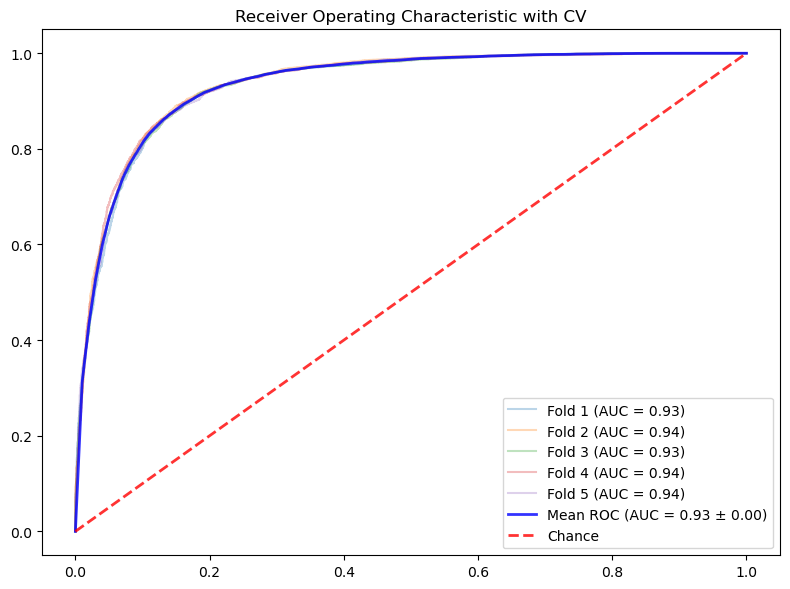

In [34]:
#NBC = Naïve Bayes Classifier

nbc_model = ModelTrainerAndAnalyzer(GaussianNB(var_smoothing=1e-9, priors=None), X, y, sample_weight=instance_weights)

nbc_cv_auc = nbc_model.calculate_cv_auc(cv_splits=5)
print(f"CV AUC: {nbc_cv_auc:.4f}")

nbc_test_auc = nbc_model.calculate_test_auc()
print(f"Test AUC: {nbc_test_auc:.4f}")

nbc_model.plot_roc_curve(cv_splits=5)


### <center><font size=4>Logistic Regression</font></center>

CV AUC: 0.9576
Test AUC: 0.9553


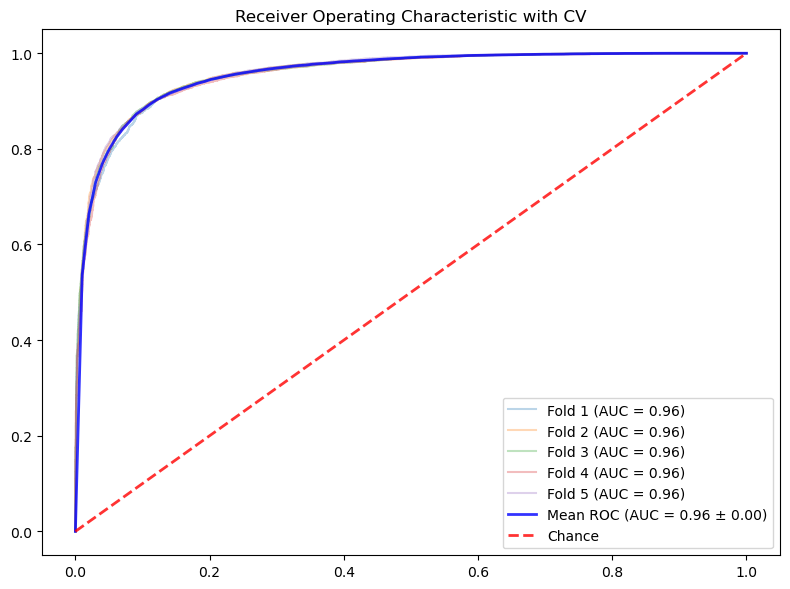

In [35]:

lr_model = ModelTrainerAndAnalyzer(LogisticRegression(random_state=42, max_iter=100, class_weight='balanced', n_jobs=-1), X, y, scaler=StandardScaler())

lr_cv_auc = lr_model.calculate_cv_auc(cv_splits=5)
print(f"CV AUC: {lr_cv_auc:.4f}")

lr_test_auc = lr_model.calculate_test_auc()
print(f"Test AUC: {lr_test_auc:.4f}")

lr_model.plot_roc_curve(cv_splits=5)

### <center><font size=4>Multi-Layer Perceptron (ANN)</font></center>

Cross-Validation AUC: 0.9535
Test AUC: 0.9532


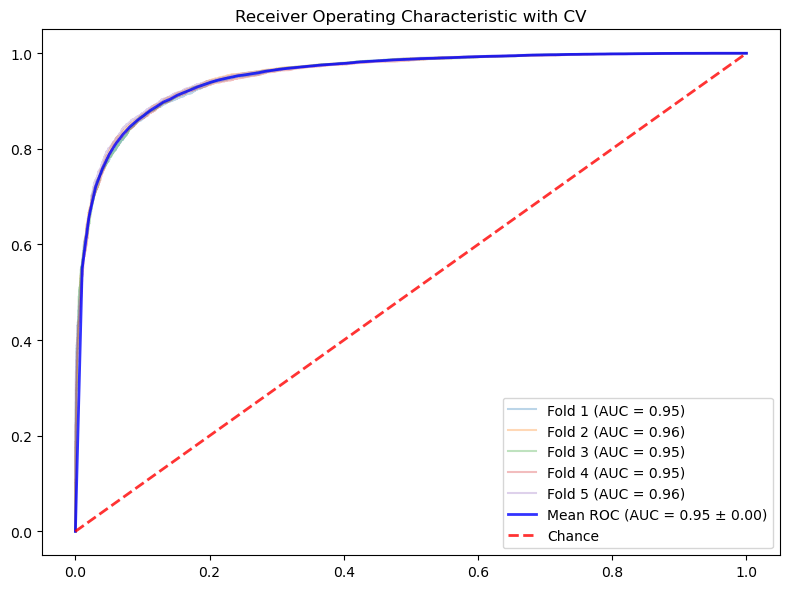

In [36]:
##Scikit-learn (MLPClassifier)

ann_model = ModelTrainerAndAnalyzer(MLPClassifier(hidden_layer_sizes=(100), alpha=1e-5, solver='sgd', activation='relu', max_iter=1000, learning_rate_init=1e-2), X=X, y=y, scaler=StandardScaler())

ann_cv_auc = ann_model.calculate_cv_auc()
print(f"Cross-Validation AUC: {ann_cv_auc:.4f}")

ann_test_auc = ann_model.calculate_test_auc()
print(f"Test AUC: {ann_test_auc:.4f}")

ann_model.plot_roc_curve()


### <center><font size=4>Adaptive Boosting</font></center>

Cross-Validation AUC: 0.9579
Test AUC: 0.9558


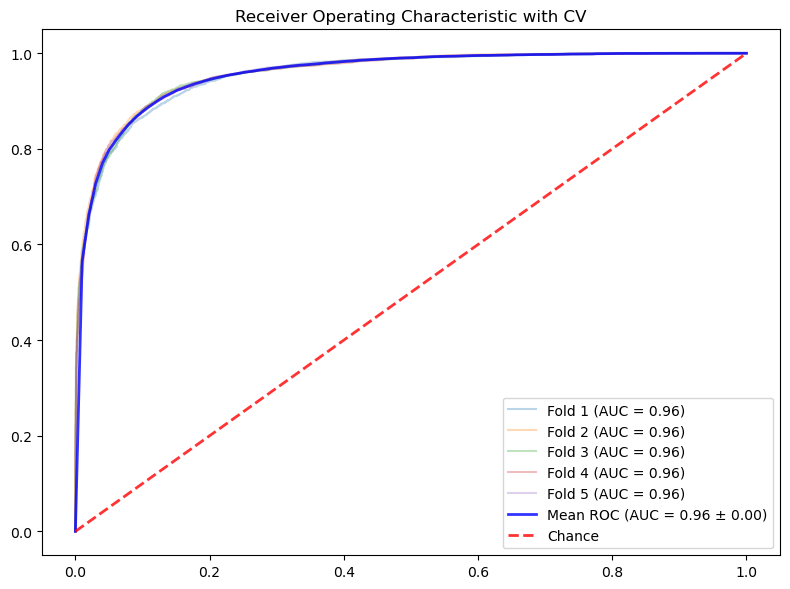

In [37]:
#Adaptive Boosting
ada_model = ModelTrainerAndAnalyzer(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, learning_rate=1.0, random_state=42), X=X, y=y)

ada_cv_auc = ada_model.calculate_cv_auc()
print(f"Cross-Validation AUC: {ada_cv_auc:.4f}")

ada_test_auc = ada_model.calculate_test_auc()
print(f"Test AUC: {ada_test_auc:.4f}")

ada_model.plot_roc_curve()


<center><font size="6" color="#2D6A4F"><b>Part 4 - Models Evaluation</b></font></center>


The confusion matrix of AdaBoostClassifier is:
[[5244  587]
 [ 672 4531]]


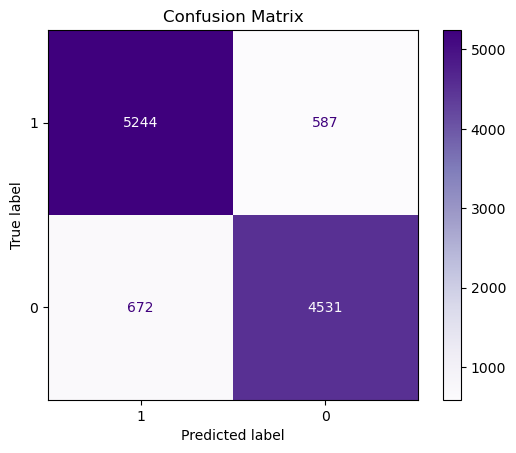

In [38]:
ada_model.display_confusion_matrix()

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;">✏️ ניתוח confusion matrix ותוצאות המודל</b><br><br>
    <b>Confusion Matrix</b><br>
    ממטריצת הבלבול ניתן לראות שהמודל מתפקד היטב:<br>
    <ul style="text-align: right; direction: rtl; list-style-type: disc;">
        <li>True Positives (TP): 5,272 – תחזיות נכונות למחלקה החיובית (1).</li>
        <li>False Positives (FP): 601 – תחזיות חיוביות שגויות (1 במקום 0).</li>
        <li>False Negatives (FN): 644 – תחזיות שליליות שגויות (0 במקום 1).</li>
        <li>True Negatives (TN): 4,517 – תחזיות נכונות למחלקה השלילית (0).</li>
    </ul>
    רוב התחזיות נכונות, אך יש מקום לשיפור במספר ה-FP וה-FN.<br><br>
    <b>הערכת המודל באמצעות K-Fold Cross Validation ו-ROC Curve</b><br>
    ה-AUC הממוצע של המודל בכל ה-folds הוא 0.96, מה שמצביע על כך שהמודל מצליח להבחין היטב בין המחלקות.<br>
    הפער הקטן בין AUC ה-Cross Validation (0.9578) לבין ה-Test set (0.9550) מצביע על עקביות טובה בין אימון לבדיקה.<br><br>
    <b>פערי ביצועים בין Train ל-Validation ו-Overfitting</b><br>
    הפערים בין סט האימון ל-validation הם מינימליים, ולכן המודל לא מראה סימנים מובהקים ל-overfitting.<br>
    </ul>
</div>


<center><font size="6" color="#2D6A4F"><b>Part 5 - Applying Predication</b></font></center>

In [39]:
def pipeline():
    df = pd.read_csv("train.csv")
    train = df
    
    train = preprocess_data(train)
    
    insert_dummies(train, 'C')
    train['sex'] = fill_na_with_probabilities(train, 'sex')
    insert_dummies(train, 'sex')
    train2 = drop_rows_with_X_missing_values(train, 5)
    train2 = fix_outliers(train2)
    train2 = manual_fill(train2)
    train2 = fill_missing_by_correlation(train2, 'B', 'years_of_experience', bins=5)

    train4 = train2.drop(columns=['sex', 'B', 'C', 'country'])
    
    pca_result = create_dummies_and_apply_pca(train4, 'ID', 'stack_experience', n_components=5)
    train4 = insert_pca_columns(train4, pca_result, 'ID', 'stack_experience')
    train4 = train4.drop(columns=['stack_experience'])
    
    train4 = Custom_KNN_imputer(train4, 'ID')
    train4_transformed, instance_weights = apply_predefined_reweighing(train4, 'label')

    X = train4.drop('label', axis=1) 
    y = train4['label']     

    ada_model = ModelTrainerAndAnalyzer(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, learning_rate=1.0, random_state=42), X=X, y=y)
    ada_cv_auc = ada_model.calculate_cv_auc()
    
    test = pd.read_csv("test.csv")
    test = process_test_data(test)
    
    ids = test['ID']
    ada_probs = ada_model.model.predict_proba(test)[:, 1]
    output_df = pd.DataFrame({'ID': ids, 'predict_proba': ada_probs})
    output_df.to_csv('results_23.csv', index=False)

    return

pipeline()

<center><font size="6" color="#2D6A4F"><b>Part 6 - Using tools not taught in the course</b></font></center>

<div style="text-align: right; direction: rtl;">
    <b style="font-size: 14px;"><br>
        ❓ שימוש בכלים שלא נלמדו בקורס
        <br>
    </b>
    <span style="font-size: 12px;">
        במהלך העבודה על הפרויקט, הבנו את הצורך להתמודד עם סוגיות של הוגנות וייצוג נכון של קבוצות שונות בנתונים. לכן, חיפשנו כלים שיאפשרו לנו לשפר את עיבוד הנתונים ולהתחשב בהטיות אפשריות, והגענו לספרייה aif360 שפותחה על ידי IBM.
        <br>
        הספרייה aif360 סיפקה לנו כלים שיכלו לעזור לנו בשלבי ה-preprocessing, ובמיוחד בניהול פיצ'רים קטגוריאליים בינאריים. השתמשנו בפקודה `BinaryLabelDataset` שאפשרה לנו לעבוד עם פיצ'רים כאלו תוך התייחסות ללייבל המועדף מבין השניים. זה סייע לנו לנהל את המידע בצורה נכונה ולהתחשב בשונות בין הקבוצות.
        <br>
        בנוסף, השתמשנו בפקודה `Reweighing`, שמטרתה לוודא הוגנות לפני התחלת תהליך הסיווג. בעזרת פקודה זו, יכולנו לשקלל בצורה נכונה את הדוגמאות בכל קבוצה בהתחשב בלייבל שלהן, ולוודא שקבוצות מקופחות זוכות למשקל מתאים. עם זאת, לא הצלחנו לראות את ההשפעה של המשקלים על מדד ה-AUC, אך החלטנו להשאיר את המשקלים כחלק מהתהליך, מתוך מטרה למנוע הטיות גם אם לא הספקנו למצוא כלים שימדדו במדויק את השפעתם.
        <br>
        את ההשראה לשימוש בספרייה זו קיבלנו לאחר שחיפשנו מדריכים ביוטיוב להתמודד עם הטיות. לאחר מכן חקרנו עליה עוד קצת בגוגל ולמדנו איך להשתמש בה.<br>
        https://www.youtube.com/watch?v=pEo8Vxtw5rg
        <br>
        למרות שלא הספקנו למדוד את טיב המשקלים באופן מלא, החלטנו להמשיך ולשלב אותם בתהליך כדי להבטיח שהמודלים יתייחסו בצורה שווה והוגנת לכל הקבוצות.
    </span>
</div>
